In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [2]:
df=pd.read_csv('traffic_data_sample.csv')

In [3]:
df.head()

,junction_id,timestamp,vehicle_count,avg_speed
0,J1,2025-01-01 06:00,62,13
1,J1,2025-01-01 06:05,172,11
2,J1,2025-01-01 06:10,104,12
3,J1,2025-01-01 06:15,113,35
4,J1,2025-01-01 06:20,92,77


### CHECKING IF THE DATA HAVE MISSING VALUES

In [4]:
df.isnull().sum()

junction_id      0
timestamp        0
vehicle_count    0
avg_speed        0
dtype: int64

In [5]:

# Convert 'timestamp' to datetime format
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

# Drop rows with invalid timestamps
df = df.dropna(subset=["timestamp"])




In [6]:
# 3. Handle vehicle count
# Replace negative values with NaN
df.loc[df["vehicle_count"] < 0, "vehicle_count"] = np.nan

df = df.dropna(subset=["vehicle_count"])



In [7]:

# 4. Handle speed values
# Replace unrealistic speeds with NaN
df.loc[(df["avg_speed"] < 0) | (df["avg_speed"] > 120), "avg_speed"] = np.nan

# Option 1: Drop rows with invalid speed
df = df.dropna(subset=["avg_speed"])

# Option 2: Fill missing speed with median
df["avg_speed"] = df["avg_speed"].fillna(df["avg_speed"].median())

In [8]:

# 5. Handle remaining missing values (if any)
df = df.dropna()

In [9]:


# 6. Final validation checks
assert (df["vehicle_count"] >= 0).all()
assert ((df["avg_speed"] >= 0) & (df["avg_speed"] <= 120)).all()



In [10]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   junction_id    300 non-null    object        
 1   timestamp      300 non-null    datetime64[ns]
 2   vehicle_count  300 non-null    float64       
 3   avg_speed      300 non-null    float64       
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 9.5+ KB
None


### AVERAGE VEHICLE COUNT PER JUNCTION

In [11]:
avg_vehicle_count = (
    df.groupby("junction_id")["vehicle_count"]
      .mean()
      .reset_index(name="avg_vehicle_count")
)

print(avg_vehicle_count)


  junction_id  avg_vehicle_count
0          J1          98.383333
1          J2          95.200000
2          J3         100.183333
3          J4         103.500000
4          J5          97.633333


### EXTRACTNG TRAFFIC PEAK HOUR

In [12]:
# Extract hour from timestamp
df["hour"] = df["timestamp"].dt.hour

peak_hour = (
    df.groupby("hour")["vehicle_count"]
      .sum()
      .idxmax()
)

print(f"Peak traffic hour: {peak_hour}:00")


Peak traffic hour: 6:00


### TOP 3 BUSIEST JUNCTION

In [13]:
top_3_busiest = (
    df.groupby("junction_id")["vehicle_count"]
      .sum()
      .nlargest(3)
      .reset_index()
)

print(top_3_busiest)


  junction_id  vehicle_count
0          J4         6210.0
1          J3         6011.0
2          J1         5903.0


### IDENTIFYING LOW-SPEED CONGESTION ZONES

In [32]:
low_speed_zones = df.groupby("junction_id")["avg_speed"].mean().reset_index(name="avg_speed")

low_speed_zones = low_speed_zones[low_speed_zones["avg_speed"] < 20]


print(low_speed_zones)


Empty DataFrame
Columns: [junction_id, avg_speed]
Index: []


### CONGESTION DETECTION LOGIC

In [15]:
# Ensure date column
df["date"] = df["timestamp"].dt.date

df["daily_avg_vehicle_count"] = (
    df.groupby(["junction_id", "date"])["vehicle_count"]
      .transform("mean")
)


In [33]:
df["congestion_flag"] = (
    (df["vehicle_count"] > 1.5 * df["daily_avg_vehicle_count"]) &
    (df["avg_speed"] < 25)
)


In [17]:
congested_events = df[df["congestion_flag"]]

print(congested_events)


    junction_id           timestamp  vehicle_count  avg_speed  hour  \
1            J1 2025-01-01 06:05:00          172.0       11.0     6   
6            J1 2025-01-01 06:30:00          162.0       20.0     6   
29           J1 2025-01-01 08:25:00          173.0       18.0     8   
69           J2 2025-01-01 06:45:00          159.0       12.0     6   
161          J3 2025-01-01 09:25:00          155.0       13.0     9   
170          J3 2025-01-01 10:10:00          176.0       14.0    10   
181          J4 2025-01-01 06:05:00          157.0       15.0     6   
192          J4 2025-01-01 07:00:00          164.0       23.0     7   
195          J4 2025-01-01 07:15:00          163.0       14.0     7   
202          J4 2025-01-01 07:50:00          174.0       15.0     7   
252          J5 2025-01-01 07:00:00          162.0       23.0     7   
290          J5 2025-01-01 10:10:00          178.0       23.0    10   

           date  daily_avg_vehicle_count  congestion_flag  
1    2025-01-01 

In [18]:
df["congestion_flag"] = df["congestion_flag"].astype(int)


In [19]:
df.head()

,junction_id,timestamp,vehicle_count,avg_speed,hour,date,daily_avg_vehicle_count,congestion_flag
0,J1,2025-01-01 06:00:00,62.0,13.0,6,2025-01-01,98.383333,0
1,J1,2025-01-01 06:05:00,172.0,11.0,6,2025-01-01,98.383333,1
2,J1,2025-01-01 06:10:00,104.0,12.0,6,2025-01-01,98.383333,0
3,J1,2025-01-01 06:15:00,113.0,35.0,6,2025-01-01,98.383333,0
4,J1,2025-01-01 06:20:00,92.0,77.0,6,2025-01-01,98.383333,0


### EDA VISUALIZATION

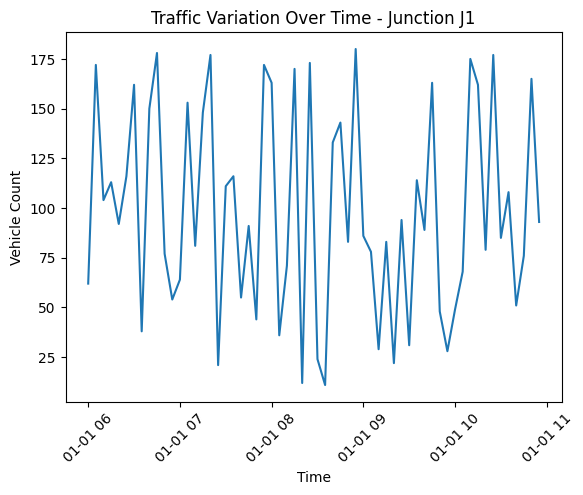

In [20]:
import matplotlib.pyplot as plt


junction_id = df["junction_id"].iloc[0]
junction_data = df[df["junction_id"] == junction_id]

plt.figure()
plt.plot(junction_data["timestamp"], junction_data["vehicle_count"])
plt.xlabel("Time")
plt.ylabel("Vehicle Count")
plt.title(f"Traffic Variation Over Time - Junction {junction_id}")
plt.xticks(rotation=45)
plt.show()


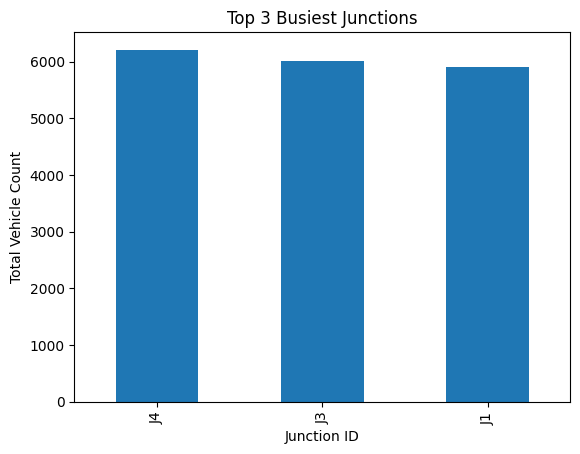

In [21]:
top_3_busiest = (
    df.groupby("junction_id")["vehicle_count"]
      .sum()
      .nlargest(3)
)

plt.figure()
top_3_busiest.plot(kind="bar")
plt.xlabel("Junction ID")
plt.ylabel("Total Vehicle Count")
plt.title("Top 3 Busiest Junctions")
plt.show()


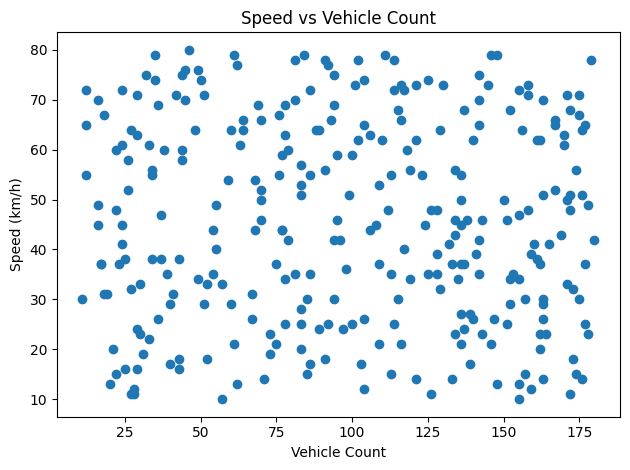

In [22]:
plt.figure()
plt.scatter(df["vehicle_count"], df["avg_speed"])
plt.xlabel("Vehicle Count")
plt.ylabel("Speed (km/h)")
plt.title("Speed vs Vehicle Count")
plt.tight_layout()
plt.show()


In [23]:
df.head()

,junction_id,timestamp,vehicle_count,avg_speed,hour,date,daily_avg_vehicle_count,congestion_flag
0,J1,2025-01-01 06:00:00,62.0,13.0,6,2025-01-01,98.383333,0
1,J1,2025-01-01 06:05:00,172.0,11.0,6,2025-01-01,98.383333,1
2,J1,2025-01-01 06:10:00,104.0,12.0,6,2025-01-01,98.383333,0
3,J1,2025-01-01 06:15:00,113.0,35.0,6,2025-01-01,98.383333,0
4,J1,2025-01-01 06:20:00,92.0,77.0,6,2025-01-01,98.383333,0


## TRAFFIC ANALYSIS SUMMARY

In [24]:

total_records = len(df) #total records

num_congestion_events = df["congestion_flag"].sum() #number of congestion events

#busiest junction
busiest_junction = (
    df.groupby("junction_id")["vehicle_count"]
      .sum()
      .idxmax()
)

#peak traffic hour

df["hour"] = df["timestamp"].dt.hour

peak_traffic_hour = (
    df.groupby("hour")["vehicle_count"]
      .sum()
      .idxmax()
)


print("     Traffic Analysis Summary     ")
print(f"Total records processed    : {total_records}")
print(f"Congestion events detected : {num_congestion_events}")
print(f"Busiest junction           : {busiest_junction}")
print(f"Peak traffic hour          : {peak_traffic_hour}:00")


     Traffic Analysis Summary     
Total records processed    : 300
Congestion events detected : 12
Busiest junction           : J4
Peak traffic hour          : 6:00


### EXPORT CONGESTION ANALYSIS

In [25]:
congested_events.to_csv("congested_events.csv", index=False)

### FEATURE EXTRACTION

In [26]:
X = df[["vehicle_count", "avg_speed", "hour"]]
y = df["congestion_flag"]

# EDA VISUALIZATION

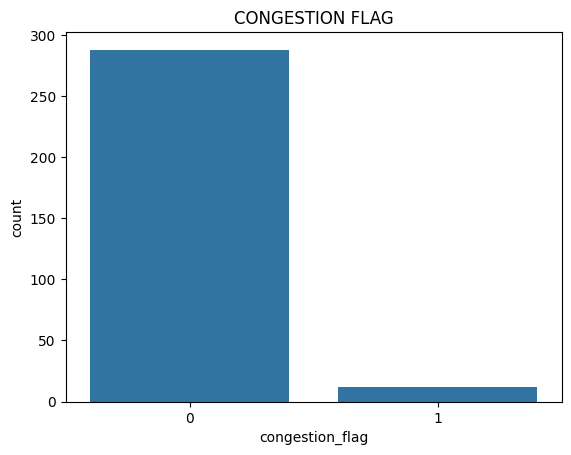

In [27]:
sns.countplot(x='congestion_flag',data=df)
plt.title("CONGESTION FLAG")
plt.show()

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## MODEL TRAINING AND VALUATION

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))



Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        59
           1       0.25      1.00      0.40         1

    accuracy                           0.95        60
   macro avg       0.62      0.97      0.69        60
weighted avg       0.99      0.95      0.96        60


Decision Tree
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        59
           1       0.50      1.00      0.67         1

    accuracy                           0.98        60
   macro avg       0.75      0.99      0.83        60
weighted avg       0.99      0.98      0.99        60


Random Forest
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        59
           1       0.50      1.00      0.67         1

    accuracy                           0.98        60
   macro avg       0.75      0.99      0.83        60
weighted avg       0.99

## CONFUSION MATRIX

In [30]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[58  1]
 [ 0  1]]


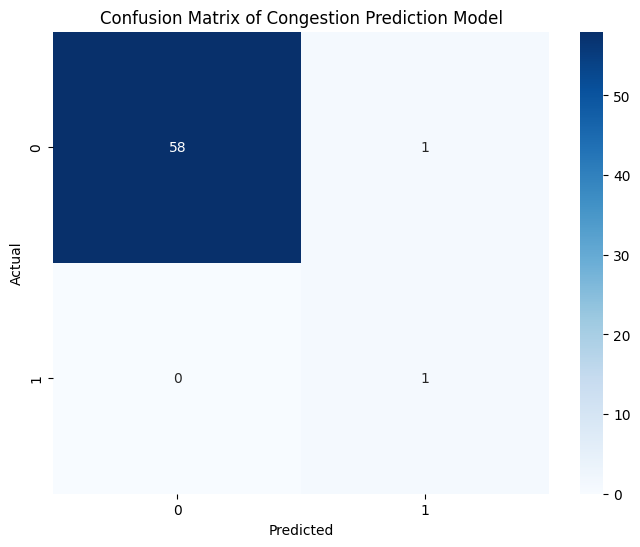

In [31]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', xticklabels=df["congestion_flag"].unique(),
            yticklabels=df["congestion_flag"].unique())
plt.title('Confusion Matrix of Congestion Prediction Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()